In [ ]:
import os
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
from scipy.stats import sem

import utils.saveload as sl
import utils.visualization as vis
import fitting_neural.load_homann_data as load_homann

# Helper functions

In [167]:
def get_opt_in_grid(grid,done,select_grid,grid_vars,plot_vars,plot_meas,type_best_worst):
    fun_best = np.nanmin #if 'mse' in plot_meas else np.nanmax if 'corr' in plot_meas else np.nanmean

    # Get best and worst samples
    if type_best_worst=='overall':
        imin = grid.loc[grid[plot_meas]==fun_best(grid[plot_meas].values.flatten()),'grid_id'].values[0]
        val_min = dict(zip(grid_vars,grid.loc[grid.grid_id==imin,grid_vars].values.flatten()))
        imin = np.array([imin])

    elif type_best_worst=='plot_var':
        grid_plot = grid.groupby(plot_vars).agg(np.nanmean).reset_index()
        val_min = dict(zip(plot_vars,grid_plot.loc[grid_plot[plot_meas]==fun_best(grid_plot[plot_meas].values.flatten()),plot_vars].values[0]))
        imin = grid.loc[(grid[plot_vars[0]]==val_min[plot_vars[0]]) & (grid[plot_vars[1]]==val_min[plot_vars[1]]),'grid_id'].values

    imin = imin[np.where(np.isin(imin,done))]
    imin = np.array([int(imin[0])],dtype=int)
    mse_min = dict(zip(select_grid,grid.loc[grid.grid_id==imin[0],select_grid].values.flatten()))
    
    return imin, val_min, mse_min

def get_grid_vars(model_type,set_name=1): # variables for which grid search was run
    if model_type=='cnov_leaky':
        grid_vars = ['alph_leak','eps','num_states_model']
    elif model_type=='cnov_fr':
        grid_vars = ['k_alph','num_states_model']

    elif 'snov' in model_type:
        # if 'complex' in model_type and set_name>5:
        #     grid_vars = ['type_complex','num_complex','knum'] 
        # elif 'leaky' in model_type:
        #     grid_vars = ['alph_leak','eps','cdens','knum']
        if 'leaky' in model_type:
            grid_vars = ['alph_leak','eps','cdens','knum']
        else:
            grid_vars = ['k_alph','cdens','knum'] 

    return grid_vars

def get_paths(model_type,set_name,str_types=''):
    if 'cnov' in model_type:
        loadpath = f'/Users/sbecker/Projects/RL_reward_novelty/data/2025_05_grid_search_new/{model_type}/'
        # loadpath = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/{model_type}/'
        savepath = f'/Volumes/lcncluster/becker/RL_reward_novelty/output/2025_05_grid_search_new/{model_type}/'
        str_types += f'_{model_type}'
    else:
        loadpath = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/{model_type}_set{set_name}_sep/combined_data/'
        savepath = f'/Volumes/lcncluster/becker/RL_reward_novelty/output/2025_05_grid_search_new/{model_type}_set{set_name}_sep/combined_data/'
        str_types += f'_{model_type}'
    sl.make_long_dir(savepath)
    return loadpath, savepath, str_types


## Plot traces

In [168]:
def plot_average_sim_sepfit(ll_model_type, ll_set_names, ll_color, ll_names, plot_meas, sampling_type='jackknife', weighting='equal-samples', drop_type='none', plot_vars=None, stat_type='min', type_best_worst='overall', plot_homann=True, inset=True, corr=True,  plot_samples=False, ylim=None, legend_pos=None):

    # Init figure
    if inset:
        fig, axl = plt.subplots(1,3,figsize=(8.2,3.2))
        if stat_type=='mean':
            ax_inset = axl[2].inset_axes([0.55,0.6,0.4,0.4])
        elif stat_type=='median':
            ax_inset = axl[2].inset_axes([0.55,0.6,0.4,0.4])
        elif stat_type=='min':
            ax_inset = axl[2].inset_axes([0.55,0.7,0.4,0.3])
        axl = np.concatenate([axl,np.array([ax_inset])])
    else:
        fig, axl = plt.subplots(1,4,figsize=(4*2.7,3.6))
    str_types = ''
    
    # Load Homann data
    homann_data = load_homann.load_exp_homann(cluster=False)
    homann_lstd = load_homann.load_exp_homann(cluster=False,type='lowerstd')
    homann_ustd = load_homann.load_exp_homann(cluster=False,type='upperstd')
    # Set novelty response for L'=0 to zero
    homann_data[1][1][0] = 0 #homann_data[1][1][0]-delta_homann
    homann_lstd[1][1][0] = 0 #homann_lstd[1][1][0]-delta_homann
    homann_ustd[1][1][0] = 0 #homann_ustd[1][1][0]-delta_homann
    
    # Plot specs (Homann)
    data_files      = ['l','lp','m','m_steady']
    data_len        = [len(homann_data[dd][0]) for dd in range(len(homann_data))]
    data_var        = ['n_fam','dN','n_im','n_im']
    data_val        = ['nt_norm','tr_norm','nt_norm','steady']
    xl_homann       = ['Sequence repetitions (L)','Recovery repetitions (L\')','Length of sequence (M)','Length of sequence (M)']
    yl_homann       = ['Novelty response $\Delta N$','$\Delta$ N','$\Delta$ N','Steady state $N_{\infty}$']

    # Load simulations for all grid points
    average_params = []
    for j, (model_type, color, name, set_name) in enumerate(zip(ll_model_type, ll_color, ll_names, ll_set_names)):

        ### Determine best parameter set ###########
        # Set load path
        loadpath, savepath, str_types = get_paths(model_type,set_name,str_types)
            
        # Load done file
        with open(loadpath + 'done.txt') as f:
            done = np.array([int(line.replace('\n','')) for line in f])
        done = np.unique(done)

        # Construct load name
        add_name    = f'{sampling_type}'
        if 'jackknife' in sampling_type or 'loo' in sampling_type:
            add_name += f'-drop-{drop_type}'
        if weighting!='none':
            add_name += f'-{weighting}'

        # Load failed samples
        if os.path.exists(loadpath + f'failed_{add_name}.txt'):
            with open(loadpath + f'failed_{add_name}.txt') as f:
                failed = np.array([int(line.replace('\n','').split(':')[0]) for line in f])
            failed = np.unique(failed)
            done = done[np.where(~np.isin(done,failed))] # remove failed samples

        if stat_type=='min':
            # Define plot variable + grid variables of interest
            plot_meas_in_grid = ('jack_' if sampling_type=='jackknife' else 'boot-mean_' if sampling_type=='bootstrap' else '') + plot_meas
            grid_vars = get_grid_vars(model_type,set_name)

            # Load grid
            grid = pd.read_csv(os.path.join(loadpath,f'grid_{add_name}.csv'))
            select_grid = grid_vars + [plot_meas] + ['grid_id'] # select grid variables + mse variables

            # Filter grid to be plotted
            if plot_vars[j]=='alph_leak':
                grid = grid[grid[plot_vars[j]]>0.01]

            # Determine best parameters
            imin, val_min, mse_min = get_opt_in_grid(grid,done,select_grid,grid_vars,plot_vars,plot_meas_in_grid,type_best_worst)
            average_params.append((f'{model_type}',{**val_min,**mse_min}))
            
            # if 'leaky' in model_type:
            #     # Get best non-leaky parameters (subgrid of leaky grid)
            #     gid_nonleaky    = grid.loc[grid['alph_leak']==0,'grid_id'].values # get non-leaky parameter sets
            #     done_nonleaky   = done[np.isin(done,gid_nonleaky)]
            #     grid_nonleaky   = grid.loc[grid['alph_leak']==0]
            #     imin_nonleaky, val_min_nonleaky, mse_min_nonleaky = get_opt_in_grid(grid_nonleaky,done_nonleaky,select_grid,grid_vars,plot_vars,plot_meas_in_grid,type_best_worst)
            #     average_params.append((f'{model_type.replace("leaky","nonleaky")}',{**val_min_nonleaky,**mse_min_nonleaky}))

            keep_grid_id = grid['grid_id'].values

            # Get single grid id for each value of the variable to be plotted (robustness check)
            grid_sorted = grid.sort_values(by=[plot_meas],ascending=True)
            alpha_grid = grid_sorted[['grid_id']+plot_vars[j]].groupby(plot_vars[j]).first()
            alpha_grid = alpha_grid['grid_id'].values
            
        else:

            keep_grid_id = done


        ### Load fitted data for best parameter set and robustness data sets ###########

        dd_sim_all      = []
        stats_sim_all   = []
        fitted_all      = []
        pred_name = 'pred'
        coef_name = 'coef_fit'

        for dd in range(len(data_files)):

            # Load fitted data files + combine into data frame
            dd_all = []
            for ii in done:
                d_ii = pd.read_csv(loadpath + f'grid_{ii}/{pred_name}_{data_files[dd]}_{weighting}.csv')
                d_ii = d_ii[:data_len[dd]+1]
                d_ii['grid_id'] = [ii]*len(d_ii)
                dd_all.append(d_ii)
            dd_all = pd.concat(dd_all)
            dd_sim_all.append(dd_all)
            
            if stat_type=='mean' or stat_type=='median':
                # Compute mean + std across parameters
                dd_stats = dd_all[[data_var[dd], data_val[dd]]].groupby([data_var[dd]]).agg([np.mean,np.median,np.std,vis.quantile25err,vis.quantile75err]).reset_index() 
                dd_fitted = [dd_stats[data_var[dd]].values,dd_stats[(data_val[dd],stat_type)].values]

            elif stat_type=='min':
                # Get best sample data
                dd_stats = dd_all.loc[dd_all['grid_id']==imin[0],[data_var[dd],data_val[dd]]]
                dd_fitted = [dd_stats[data_var[dd]].values,dd_stats[data_val[dd]].values]
                
            stats_sim_all.append(dd_stats)
            fitted_all.append(dd_fitted)

        ### Plot fitted data for best parameter sets / robustness parameter sets ###########
        for dd in range(len(data_files)):
            ax = axl[dd]
            if dd==len(axl)-1 and inset:
                markersize = 3
                label_font = 10
                plot_line = False
            else:
                markersize = 6
                label_font = 11
                plot_line = True

            # Plot robustness samples 
            if plot_samples:

                dd_sim       = dd_sim_all[dd]
                max_plot_sim = 36
                done_plot    = list(set(done).intersection(set(keep_grid_id)).intersection(set(alpha_grid)))

                if len(done_plot)>max_plot_sim:
                    done_plot = np.random.choice(done_plot,max_plot_sim,replace=False)
                    # done_plot = done_plot[:max_plot_sim]

                for ii in done_plot:
                    dd_ii = dd_sim[dd_sim.grid_id==ii] 

                    # if 'leaky' in model_type and (ii in gid_nonleaky):
                    #     col_ii = 'darkgreen' if 'cnov' in model_type else 'purple'
                    # else:
                    #     col_ii = color[-1]
                    col_ii = color[-1]

                    if dd==len(data_files)-1:
                        ax.plot(homann_data[dd][0],dd_ii[data_val[dd]].values,'+',markersize=markersize/2,c=col_ii,alpha=0.4)
                    else:
                        ax.plot(homann_data[dd][0],dd_ii[data_val[dd]].values,'-',lw=0.85,c=col_ii,alpha=0.4)

            # Plot winning model samples 
            xx = homann_data[dd][0]

            if stat_type=='min':

                yy_fit = pd.read_csv(os.path.join(loadpath,f'grid_{imin[0]}/{coef_name}_{weighting}.csv'))

                if 'cnov' in model_type:
                    yy_data = pd.read_csv(os.path.join(loadpath,f'grid_{imin[0]}/{pred_name}_{data_files[dd]}_{weighting}.csv'))
                    yy = yy_data[data_val[dd]]
                    yerrl = np.zeros(len(yy))
                    yerru = np.zeros(len(yy))

                    # if 'leaky' in model_type:
                        # yy_fit_nonleaky = pd.read_csv(os.path.join(loadpath,f'grid_{imin_nonleaky[0]}/{coef_name}_{weighting}.csv'))
                        # yy_data_nonleaky = pd.read_csv(os.path.join(loadpath,f'grid_{imin_nonleaky[0]}/{pred_name}_{data_files[dd]}_{weighting}.csv'))
                        # yy_nonleaky = yy_data_nonleaky[data_val[dd]]
                        # yerrl_nonleaky = np.zeros(len(yy_nonleaky))
                        # yerru_nonleaky = np.zeros(len(yy_nonleaky))

                else:
                    if isinstance(set_name,int):
                        yy_stats = pd.read_csv(os.path.join(loadpath,f'grid_{imin[0]}/stats_{data_files[dd]}.csv'))

                        yy = yy_stats[data_val[dd]].values * yy_fit['coef'].values[0] 
                        if 'steady' in data_files[dd]:
                            yy = yy + yy_fit['shift'].values[0]
                        yerrl = np.nan * np.ones(len(yy))
                        yerru = np.nan * np.ones(len(yy))
                    
                    else:
                        yy_data = pd.read_csv(os.path.join(loadpath,f'grid_{imin[0]}/data_all_{data_files[dd]}.csv'))
                        dv = data_val[dd]
                        yy_data['pred'] = yy_data[dv].values * yy_fit['coef'].values[0] 

                        if 'steady' in data_files[dd]:
                            yy_data['pred'] = yy_data['pred'].values + yy_fit['shift'].values[0]

                        yy_stats = yy_data[[data_var[dd],'pred']].groupby([data_var[dd]]).agg([np.mean, np.std, sem]).reset_index()

                        yy = yy_stats[('pred','mean')].values
                        yerrl = yy_stats[('pred','sem')].values
                        yerru = yy_stats[('pred','sem')].values

                    # if 'leaky' in model_type:
                    #     yy_fit_nonleaky  = pd.read_csv(os.path.join(loadpath,f'grid_{imin_nonleaky[0]}/{coef_name}_{weighting}.csv'))
                    #     yy_data_nonleaky = pd.read_csv(os.path.join(loadpath,f'grid_{imin_nonleaky[0]}/data_all_{data_files[dd]}.csv'))

                    #     dv = data_val[dd]
                    #     yy_data_nonleaky['pred'] = yy_data_nonleaky[dv].values * yy_fit_nonleaky['coef'].values[0] 

                    #     if 'steady' in data_files[dd]:
                    #         yy_data_nonleaky['pred'] = yy_data_nonleaky['pred'].values + yy_fit_nonleaky['shift'].values[0]

                    #     yy_stats_nonleaky = yy_data_nonleaky[[data_var[dd],'pred']].groupby([data_var[dd]]).agg([np.mean, np.std, sem]).reset_index()
                    #     yy_nonleaky       = yy_stats_nonleaky[('pred','mean')].values
                    #     yerrl_nonleaky    = yy_stats_nonleaky[('pred','sem')].values
                    #     yerru_nonleaky    = yy_stats_nonleaky[('pred','sem')].values
            else:

                yy = stats_sim_all[dd][(data_val[dd],stat_type)].values

                if stat_type=='mean':
                    yerrl = stats_sim_all[dd][(data_val[dd],'std')].values
                    yerru = stats_sim_all[dd][(data_val[dd],'std')].values

                elif stat_type=='median':
                    yerrl = stats_sim_all[dd][(data_val[dd],'quantile25err')].values
                    yerru = stats_sim_all[dd][(data_val[dd],'quantile75err')].values

            ax.plot(xx,yy,'o',c=color[-1],markersize=markersize)

            # if 'leaky' in model_type:
            #     col_leaky = 'darkgreen' if 'cnov' in model_type else 'purple'
            #     ax.plot(xx,yy_nonleaky,'o',c=col_leaky,markersize=markersize)

            if plot_line:
                ax.plot(xx,yy,'-',c=color[-1],label=name,lw=2)
                ax.errorbar(x=xx,y=yy,yerr=[yerrl,yerru],c=color[-1],capsize=2,fmt='none')

                # if 'leaky' in model_type:
                #     ax.plot(xx,yy_nonleaky,'-',c=col_leaky,label=name + '\n(non-leaky)',lw=2)
                    # ax.errorbar(x=xx,y=yy_nonleaky,yerr=[yerrl_nonleaky,yerru_nonleaky],c=col_leaky,capsize=2,fmt='none')

            else:
                ax.errorbar(x=xx,y=yy,yerr=[yerrl,yerru],c=color[-1],capsize=2,fmt='none')

                # if 'leaky' in model_type:
                #     ax.errorbar(x=xx,y=yy_nonleaky,yerr=[yerrl_nonleaky,yerru_nonleaky],c=col_leaky,capsize=2,fmt='none')

            ax.set_xlabel(xl_homann[dd],loc='center',fontsize=label_font)

            if dd==0:
                ax.set_ylabel(yl_homann[dd],fontsize=label_font)
            elif dd==len(data_files)-1:
                ax.set_ylabel(yl_homann[dd],fontsize=label_font)
    
    # Plot Homann data
    if plot_homann:
        str_types += '_homann'
        for i in range(len(data_files)):
            ax = axl[i]
            if i==len(axl)-1 and inset:
                markersize = 3
                plot_line = False
            else:
                markersize = 6
                plot_line = True
            ax.plot(homann_data[i][0],homann_data[i][1],'o',c='k',markersize=markersize)
            ax.errorbar(x=homann_data[i][0],y=homann_data[i][1],yerr=[homann_data[i][1]-homann_lstd[i][1],homann_ustd[i][1]-homann_data[i][1]],c='k',capsize=2,fmt='none')
            if plot_line: 
                ax.plot(homann_data[i][0],homann_data[i][1],'-',c='k',label='Homann et al.')
        
    # Format figure
    yeps = 0.0025
    if stat_type=='mean' and ylim is None:
        ylim = [[0,0.05],[0,0.05],[0,0.07],[0.04,0.1]]
    elif stat_type=='median' and ylim is None:
        ylim = [[0,0.05],[0,0.05],[0,0.07],[0.04,0.1]]
    elif stat_type=='min' and ylim is None:
        ylim = [[0,0.05],[0,0.05],[0,0.06],[0.04,0.1]]
    xlim = [[0-0.9,40+0.9],[0-4,150+4],[3-0.5,12+0.5],[3-0.5,12+0.5]]
    xt = [[0,20,40],[0,50,100,150],[3,6,9,12],[3,6,9,12]]
    for i in range(len(axl)):
        axl[i].set_ylim(np.array(ylim[i])+yeps*np.array([-1,1]))
        axl[i].set_xlim(np.array(xlim[i]))
        axl[i].set_xticks(xt[i])
        axl[i].set_xticklabels(xt[i])
        axl[i].spines['right'].set_visible(False)
        axl[i].spines['top'].set_visible(False)
    if stat_type=='mean' and legend_pos is None:
        axl[0].legend(fontsize=10,loc=(0.2,0.1),handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)
    elif stat_type=='median' and legend_pos is None:
        axl[0].legend(fontsize=10,loc=(0.2,0.1),handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)
    elif stat_type=='min' and legend_pos is None:
        axl[0].legend(fontsize=10,loc=(0.2,0.1),handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)
    else:
        axl[0].legend(fontsize=10,loc=legend_pos,handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)
    if inset:
        axl[-1].set_xlabel('')
        axl[-1].xaxis.set_tick_params(labelsize=10)
        axl[-1].yaxis.set_tick_params(labelsize=10)
    fig.tight_layout(pad=0.4)

    # Save figure
    figname = f'best-sim_{"-samples" if plot_samples else ""}' + str_types + add_name + '.svg'
    fig.savefig(savepath + figname) 
        
    print('done')
    return average_params


## Plot stats

In [169]:
def plot_single_var(ll_model_type,ll_set_names,ll_color,ll_names,plot_var,plot_meas,xl,yl,xt,yt,regr_meas='score',sampling_type='jackknife',drop_type='sample',weighting='equal-samples',best_params=None,corr=True,f=None,ax=None,legend=False,legend_color=False,legend_symbol=False,w_meas_ll=None,plot_sep_exp=False,add_name=''):
    
    # Init default values
    if w_meas_ll is None:
        w_meas_ll = np.array([1]*len(plot_meas.split('+')))
    if ll_set_names is None:
        ll_set_names = ['1']*len(ll_model_type)

    # Init figure
    if f is None or ax is None:
        fig,ax = plt.subplots(1,1,figsize=(2,2)) #figsize=(2.25,1.9)
        set_figtight = True
    else:
        set_figtight = False
    
    # Init string for savename
    str_types = ''
    if best_params is not None:
        bs_models = [bp[0] for bp in best_params]
        bs_params = [bp[1] for bp in best_params]

    # Load Homann data
    homann_data = load_homann.load_exp_homann(cluster=False)
    homann_data[1][1][0] = 0 # set novelty response for L'=0 to zero

    # Load and plot data
    for i_model, (model_type, color, set_name) in enumerate(zip(ll_model_type,ll_color,ll_set_names)):

        # Set load path
        loadpath, savepath, str_types = get_paths(model_type,set_name,str_types)
        
        # Variables of the grid search
        plot_meas_in_grid = ('jack_' if sampling_type=='jackknife' else 'boot-mean_' if sampling_type=='bootstrap' else '') + plot_meas
        grid_vars = get_grid_vars(model_type,set_name)

        # Construct load name
        # add_name    = f'{regr_meas}-{sampling_type}'
        add_name    = f'{sampling_type}'
        if 'jackknife' in sampling_type or 'loo' in sampling_type:
            add_name += f'-drop-{drop_type}'
        if weighting!='none':
            add_name += f'-{weighting}'

        # Load grid
        grid = pd.read_csv(os.path.join(loadpath,f'grid_{add_name}.csv'))
        select_grid = grid_vars + [gc for gc in grid.columns if regr_meas in gc] + ['grid_id'] # select grid variables + mse variables

        # Add percentage of simple/complex cells (if applicable)
        if 'complex' in model_type and plot_var=='complex_perc':
            grid['simple_total']  = grid['type_complex']*grid['knum']                                   # total number of simple cells
            grid['complex_total'] = grid['num_complex']*grid['knum']                                    # total number of complex cells (on average)
            grid['simple_perc']   = grid['simple_total']/(grid['simple_total']+grid['complex_total'])   # percentage of simple cells
            grid['complex_perc']  = 1-grid['simple_perc']                                               # percentage of complex cells
            select_grid = select_grid + ['complex_perc']
    
        # Plot variables
        if not plot_sep_exp: 
            # Plot all plot_meas across given plot_var
            if 'mse' in plot_meas and 'corr' in plot_meas:
                plot_meas_all = ['mse_tmem+corr_tmem','mse_trec+corr_trec','mse_tem+corr_tem',plot_meas]
            elif 'mse' in plot_meas:
                plot_meas_all = ['mse_trec','mse_tmem','mse_tem',plot_meas]
            elif 'corr' in plot_meas:
                plot_meas_all = ['corr_trec','corr_tmem','corr_tem',plot_meas]
            plot_alpha = [1,1,1,1]
            plot_marker = ['left','right','none','full']

        else:
            # Plot each plot_meas separately
            plot_meas_all = [plot_meas]
            plot_alpha = [1]
            plot_marker = ['full']

        print(f'{plot_var}: ({np.min(grid[plot_var]), np.max(grid[plot_var])})')

        for i_pm, (pm, am, fm) in enumerate(zip(plot_meas_all,plot_alpha,plot_marker)):
            grid_plot = grid[[plot_var, pm]].groupby([plot_var]).agg(mean=(pm,np.nanmean),min=(pm,np.nanmin),max=(pm,np.nanmax)).reset_index()

            # Plot mses from individual experiments + plot_meas
            col_ls = '-' if pm==plot_meas else '--'

            if legend_symbol or legend:
                ls = "L exp." if 'tem' in pm else "L\' exp." if 'trec' in pm else "M exp." if 'tmem' in pm else "Exp. combined"
                # ax.plot(grid_plot[plot_var],grid_plot['mean'],'o',c=color[i_pm],fillstyle=fm,alpha=am,label=ls)
                ax.plot(grid_plot[plot_var],grid_plot['min'],'o',c=color[i_pm],fillstyle=fm,alpha=am)

            else: 
                # ax.plot(grid_plot[plot_var],grid_plot['mean'],'o',c=color[i_pm],fillstyle=fm,alpha=am)
                ax.plot(grid_plot[plot_var],grid_plot['min'],'o',c=color[i_pm],fillstyle=fm,alpha=am)

            if legend_color and fm=='full':
                ls = ll_names[i_model]
                ax.plot(grid_plot[plot_var],grid_plot['min'],'o',c=color[i_pm],fillstyle=fm,alpha=am,label=ls)
    
            ax.plot(grid_plot[plot_var],grid_plot['min'],ls=col_ls,c=color[i_pm],alpha=am) 

        # Plot best-sample point and best MSE of opposite model
        if best_params is not None:
            if f'{model_type}' in bs_models:
                idx = bs_models.index(f'{model_type}')
                plot_best = True
            else:
                plot_best = False

            if plot_best:
                # Best sample point
                if plot_var in bs_params[idx].keys():
                    best_var = bs_params[idx][plot_var] 
                    # if plot_var=='k_alph' and model_type=='cnov_leaky':
                    #     best_var = 1-best_var
                    best_mse = bs_params[idx][plot_meas]
                    if legend:
                        ax.plot(best_var,best_mse,'x',c='k',linewidth=3,label='Best')
                    else:
                        ax.plot(best_var,best_mse,'x',c='k',linewidth=3)

    # Format plot
    ax.set_xlabel(xl)
    ax.set_xlim([min(xt),max(xt)])
    if plot_var in ['eps', 'num_states_model']:    
        ax.set_xscale('log')
        # ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
    else:
        ax.set_xticks(xt)
    
    ax.set_ylabel(yl)
    ax.set_yticks(yt)
    if regr_meas!='score':
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    ax.set_ylim([min(yt),max(yt)])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    figname = f'{plot_meas}_{plot_var}' + str_types + add_name + '.svg'
    if set_figtight:
        fig.tight_layout()
        fig.savefig(os.path.join(savepath,figname))
    else:
        return savepath, figname


# Make plots

In [170]:
# Specify which comparison measure to use: normalized MSE (NMSE) or plain MSE
sampling_type = 'normal'                # 'bootstrap','jackknife-loo', 'normal'
weighting     = 'equal-samples'         # 'equal-samples', 'equal-exp' or 'none' [not available yet for bootstrap!]
drop_type     = 'sample'                  # 'sample' or 'exp' (drop one sample or one experiment - only has effect if 'jackknife' or 'loo' in sampling_type); recommended to choose drop consistent with weighting!
if sampling_type=='normal' or sampling_type=='bootstrap':
    drop_type = 'none' # no drop for normal sampling

In [171]:
##############################################################################################
#           Plot specifications                                                              #
##############################################################################################
plt.rcParams.update({'font.size': 11}) 

# Color maps (main figure)
vmax   = 4 + 2
cnorm  = colors.Normalize(vmin=0, vmax=vmax)
cmap_b = plt.cm.get_cmap('Blues')
smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b) # blue (cnov)
cmap_r = plt.cm.get_cmap('Reds')
smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r) # red (snov-complex)
cb = [smap_b.to_rgba(i) for i in range(vmax)][::-1] + [smap_r.to_rgba(i) for i in range(vmax)]

# Color maps (control figures)
vmax2  = vmax*2+1
cmap2  = plt.cm.get_cmap('PiYG')
cnorm2 = colors.Normalize(vmin=0, vmax=vmax2)
smap2  = cm.ScalarMappable(norm=cnorm2, cmap=cmap2)  # purple (snov-simple)
cb2    = [smap2.to_rgba(i) for i in range(vmax2+1)] 

cmap3  = plt.cm.get_cmap('PuOr')
cnorm3 = colors.Normalize(vmin=0, vmax=vmax2)
smap3  = cm.ScalarMappable(norm=cnorm3, cmap=cmap3)  # purple (snov-simple)
cb3    = [smap3.to_rgba(i) for i in range(vmax2+1)] 

# Specs for grid search plots: error type 
plot_meas  = 'train_mse' # 'mse_mean', 'mse_comb', 'mse_comb+corr_comb', 'corr_mean', 'corr_comb', ...
error_type = 'sem' # 'sem' or 'std'
regr_meas  = 'mse'

yl_dict = {'train_mse':'Train MSE', 
            'test_mse':'Test MSE',
            'mse_mean':'Av. NMSE', 
            'mse_comb':'Comb. NMSE', 
            'mse_comb+corr_mean':'Comb. MSE - Av. corr.', 
            'corr_mean':'- Av. corr.', 
            'corr_comb':'- Comb. corr.'}

# Specs for grid search plots: y-ticks + labels
yl = yl_dict[plot_meas] if plot_meas in yl_dict else 'MSE'
yt = [[0,7,14]] if 'score' in plot_meas else [[0,1.5e-5]] if 'mse' in plot_meas else [[-1,-0.5,0]]
    
##############################################################################################
#           Specify models to plot                                                           #
##############################################################################################
# Best fit results (main figure)
plot_leaky    = True
plot_simple   = False
ll_set_names  = [None, 9 if plot_leaky else '7-8']
ll_model_type = ['cnov'+('_leaky' if plot_leaky else '_fr'),
                    'snov'+('-simple' if plot_simple else '-complex')+('-leaky' if plot_leaky else '-fr')]
ll_k_type     = ['','triangle']
ll_names      = ['Count-based','Similarity-based'] 
ll_color      = [[cb[3],cb[2],cb[1],cb[0]], [cb[-4],cb[-3],cb[-2],cb[-1]]] # blue, red

ylim          = None
legend_pos    = None

# Grid search plots (main figure)
plot_var = [['alph_leak', 'eps', 'num_states_model'], 
            ['alph_leak', 'eps', 'cdens', 'knum']] 
xl       = [['Leakiness', 'Prior', '# states'],
            ['Leakiness', 'Prior', 'Conv. density', '# conv. comp.']] 
xt       = [[[0,0.5,1], [1e-6,1e-1], [13, 63, 513, 5013]],
            [[0,0.5,1], [1e-6,1e-1], [4,8,16,32], [2,4,6,8,10]]] 

manual_sim_params = [
pd.DataFrame({'alph_leak':[0.1],'eps':[1],'num_states_model':[13]}, index=[0]), 
pd.DataFrame({'knum':[4],'cdens':[8],'alph_leak':[0.5],'eps':[1]}, index=[0])                
]

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_10424/2295155777.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_10424/2295155777.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_10424/2295155777.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2  = plt.

## Plot robustness (simulated traces)

In [ ]:
#####################################################################################################################
#          Plot best simulation                                                                                     #
#####################################################################################################################
savepath_bestparams = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/data_for_figures/'
add_name            = f'{sampling_type}'
if 'jackknife' in sampling_type or 'loo' in sampling_type:
    add_name += f'-drop-{drop_type}'
if weighting!='none':
    add_name += f'-{weighting}'
savename_bestparams = f'best_params_{plot_meas}_{add_name}' + ('-leaky' if plot_leaky else '-fr') + ('-simple' if plot_simple else '') + '.json'

best_params = plot_average_sim_sepfit(ll_model_type=ll_model_type,
                                                  ll_set_names=ll_set_names,
                                                  ll_color=ll_color,
                                                  ll_names=ll_names, 
                                                  plot_meas=plot_meas, 
                                                  sampling_type=sampling_type,
                                                  weighting=weighting,
                                                  drop_type=drop_type,
                                                  plot_vars=[['alph_leak'],['alph_leak']], 
                                                  stat_type='min', 
                                                  plot_homann=True, 
                                                  inset=True, 
                                                  corr=True, 
                                                  plot_samples=True, 
                                                  ylim=ylim, 
                                                  legend_pos=legend_pos)

# Save best parameters
sl.make_long_dir(savepath_bestparams)
with open(os.path.join(savepath_bestparams,savename_bestparams), 'w') as fout:
    json.dump(best_params, fout)



## Plot robustness (stats)

In [175]:
savepath_bestparams = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/data_for_figures/'
add_name            = f'{sampling_type}'
if 'jackknife' in sampling_type or 'loo' in sampling_type:
    add_name += f'-drop-{drop_type}'
if weighting!='none':
    add_name += f'-{weighting}'
savename_bestparams = f'best_params_{plot_meas}_{add_name}' + ('-leaky' if plot_leaky else '-fr') + ('-simple' if plot_simple else '') + '.json'

# Load best parameters for follow-up plots
savepath = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/data_for_figures/'
with open(os.path.join(savepath_bestparams,savename_bestparams), 'r') as fin:
    best_params = json.load(fin)

print(best_params)
# best_params = [best_params[0], best_params[2]]

[['cnov_leaky', {'alph_leak': 0.01, 'eps': 5.0, 'num_states_model': 5013.0, 'train_mse': 1.9984534412685823e-06, 'grid_id': 323.0}], ['snov-complex-leaky', {'alph_leak': 0.2, 'eps': 1e-06, 'cdens': 8.0, 'knum': 2.0, 'train_mse': 7.294218269199547e-07, 'grid_id': 233.0}]]


In [176]:
best_params

[['cnov_leaky',
  {'alph_leak': 0.01,
   'eps': 5.0,
   'num_states_model': 5013.0,
   'train_mse': 1.9984534412685823e-06,
   'grid_id': 323.0}],
 ['snov-complex-leaky',
  {'alph_leak': 0.2,
   'eps': 1e-06,
   'cdens': 8.0,
   'knum': 2.0,
   'train_mse': 7.294218269199547e-07,
   'grid_id': 233.0}]]

### Old (separate panels)

In [ ]:
######################################################################################################################
#          Plot grid search results (main figure)                                                                   #
######################################################################################################################
# Plot error panels snov and cnov into single figure
num_panels = np.max([len(plot_var[i]) for i in range(len(plot_var))])
width_ratios = [1]*(num_panels) # 2 for each panel, 1 for legend
fig,axl = plt.subplots(2,num_panels,figsize=(8.3,4),gridspec_kw={'width_ratios':width_ratios}) #figsize=(2.25,1.9)

best_params = [best_params[0],best_params[2]]
# Plot grid search av. MSE
for i in range(len(plot_var)):
    all_yt          = [yt[0]]*len(plot_var[i]) 
    add_legend_col  = [True] + [False]*(len(plot_var[i])-1)
    for ii in range(len(plot_var[i])):                
        sp, fn = plot_single_var(ll_model_type=[ll_model_type[i]],
                                    ll_set_names=[ll_set_names[i]],
                                    ll_color=[ll_color[i][::-1]],
                                    ll_names=[ll_names[i]],
                                    plot_var=plot_var[i][ii],
                                    best_params=None,
                                    plot_meas=plot_meas,
                                    regr_meas=regr_meas,
                                    plot_sep_exp=True,
                                    sampling_type=sampling_type,
                                    xl=xl[i][ii],
                                    yl=yl,
                                    xt=xt[i][ii],
                                    yt=yt[0],
                                    f=fig,
                                    ax=axl[i,ii],
                                    legend_color=add_legend_col[ii],
                                    legend_symbol=i==0)
        if ii>0:
            axl[i,ii].set_ylabel('')
    
    if i==0:
        axl[i,-1].spines[['right','top','left','bottom']].set_visible(False)
        axl[i,-1].set_xticks([]); axl[i,-1].set_yticks([])

# fig.legend(ncol=1,loc='center right',bbox_to_anchor=(1,0.5),fontsize=10,frameon=False,handlelength=1.2,handletextpad=0.4,columnspacing=0.8)
fig.tight_layout()
\
# Save plot
save_str = 'grid-search'
for i in range(len(ll_model_type)):
    if 'cnov' in ll_model_type[i]:
        save_str += f'_{ll_model_type[i]}'
    else:
        save_str += f'_{ll_model_type[i]}-{ll_set_names[i]}'

savepath = f'/Volumes/lcncluster/becker/RL_reward_novelty/output/2025_05_grid_search_new/figures/'
figname = f'{save_str}.svg'
sl.make_long_dir(savepath)
fig.savefig(os.path.join(savepath,figname))

### New (combined panels)

Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
alph_leak: ((0.0, 0.999))
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
eps: ((1e-06, 50.0))
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
num_states_model: ((13, 5013))
Current path:/Users/sbecker/Projects/RL_reward_no

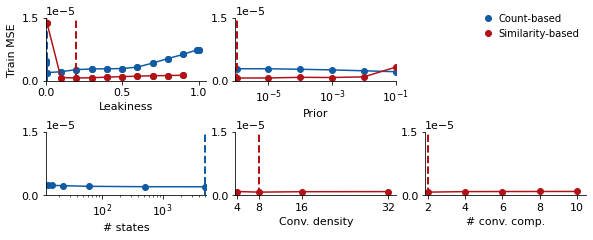

In [177]:
######################################################################################################################
#          Plot grid search results (main figure)                                                                   #
######################################################################################################################
# Plot error panels snov and cnov into single figure
fig,axl_raw = plt.subplots(2,3,figsize=(8.1,3.2)) 
axl = np.array([[axl_raw[0,0], axl_raw[0,1], axl_raw[1,0], axl_raw[0,2]], # cnov
                [axl_raw[0,0], axl_raw[0,1], axl_raw[1,1], axl_raw[1,2]]]) # snov

# Plot grid search av. MSE
for i in range(len(plot_var)):
    all_yt          = [yt[0]]*len(plot_var[i]) 
    add_legend_col  = [True] + [False]*(len(plot_var[i])-1)
    best_params_i   = best_params[i][1]

    for ii in range(len(plot_var[i])):                
        sp, fn = plot_single_var(ll_model_type=[ll_model_type[i]],
                                    ll_set_names=[ll_set_names[i]],
                                    ll_color=[ll_color[i][::-1]],
                                    ll_names=[ll_names[i]],
                                    plot_var=plot_var[i][ii],
                                    best_params=None,
                                    plot_meas=plot_meas,
                                    regr_meas=regr_meas,
                                    plot_sep_exp=True,
                                    sampling_type=sampling_type,
                                    xl=xl[i][ii],
                                    yl=yl,
                                    xt=xt[i][ii],
                                    yt=yt[0],
                                    f=fig,
                                    ax=axl[i,ii],
                                    legend_color=add_legend_col[ii],
                                    legend_symbol=i==0)

        axl[i,ii].axvline(x=best_params_i[plot_var[i][ii]],ls='--',c=ll_color[i][-1],lw=2)
        axl[i,ii].set_xlim(axl[i,ii].get_xlim()[0]*0.92,axl[i,ii].get_xlim()[1]*1.05)

        if ii>0:
            axl[i,ii].set_ylabel('')
    
    if i==0:
        axl[i,-1].spines[['right','top','left','bottom']].set_visible(False)
        axl[i,-1].set_xticks([]); axl[i,-1].set_yticks([])

    if i==0 and ii==0:
        axl[i,ii].set_xscale('log')

fig.legend(ncol=1,loc='upper right',bbox_to_anchor=(1,1),fontsize=10,frameon=False,handlelength=1.2,handletextpad=0.4,columnspacing=0.8)
fig.tight_layout(pad=0.2)

# Save plot
save_str = 'grid-search'
for i in range(len(ll_model_type)):
    if 'cnov' in ll_model_type[i]:
        save_str += f'_{ll_model_type[i]}'
    else:
        save_str += f'_{ll_model_type[i]}-{ll_set_names[i]}'

savepath = f'/Volumes/lcncluster/becker/RL_reward_novelty/output/2025_05_grid_search_new/figures/'
figname = f'{save_str}.svg'
sl.make_long_dir(savepath)
fig.savefig(os.path.join(savepath,figname))